In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
%matplotlib inline

In [2]:
filename = 'earthquake_data_tsunami.csv'
df = pd.read_csv(filename)
df.head(1)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.0,-9.7963,159.596,2022,11,1


In [3]:
df.isnull().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [4]:
df.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')

In [5]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [6]:
# featuring trignometric latitude and longitude
df['lat_sin'] = np.sin(np.radians(df['latitude']))
df['lat_cos'] = np.cos(np.radians(df['latitude']))
df['lon_sin'] = np.sin(np.radians(df['longitude']))
df['lon_cos'] = np.cos(np.radians(df['longitude']))
df.head(1)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami,lat_sin,lat_cos,lon_sin,lon_cos
0,7.0,8,7,768,117,0.509,17.0,14.0,-9.7963,159.596,2022,11,1,-0.170146,0.985419,0.348637,-0.937258


In [8]:
fig = px.scatter_geo(df,
                        lat='latitude',
                        lon='longitude',
                        color='magnitude',
                        projection='natural earth'
)
fig.update_geos(showland=True, landcolor="LightGreen")
fig.show()

In [10]:
fig = px.scatter(df,
                x='Year',
                y='Month',
                color='magnitude')
fig.show()

In [12]:
fig = px.scatter(df, 
                x = 'Month',
                y = 'magnitude',
                color = 'tsunami')
fig.show()

C:\Users\KUSHANKUR\AppData\Local\Temp\ipykernel_9972\4030625739.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




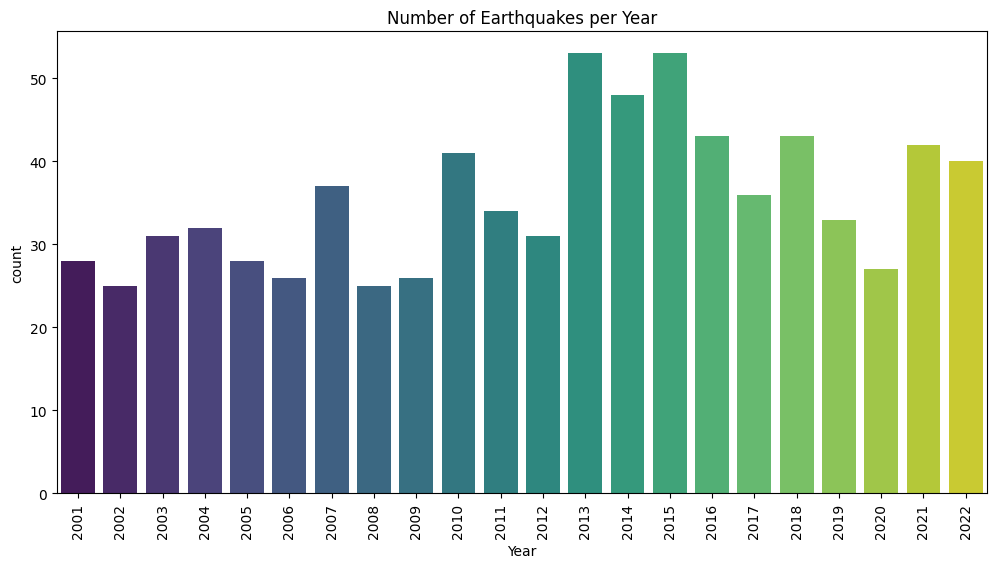

In [13]:
# year count
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Year', palette='viridis')
plt.title('Number of Earthquakes per Year')
plt.xticks(rotation=90)
plt.show()

In [14]:
df.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami', 'lat_sin',
       'lat_cos', 'lon_sin', 'lon_cos'],
      dtype='object')

In [15]:
input_cols = ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'Month', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']
target_col = 'tsunami'

In [16]:
from sklearn.model_selection import train_test_split
X = df[input_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((625, 13), (157, 13), (625,), (157,))

In [17]:
X_train.head(1)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,Month,lat_sin,lat_cos,lon_sin,lon_cos
602,6.6,8,8,831,782,0.0,16.7,12.0,7,0.609246,0.792981,0.663326,-0.748331


In [18]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8280254777070064

In [19]:
model.get_depth()

13

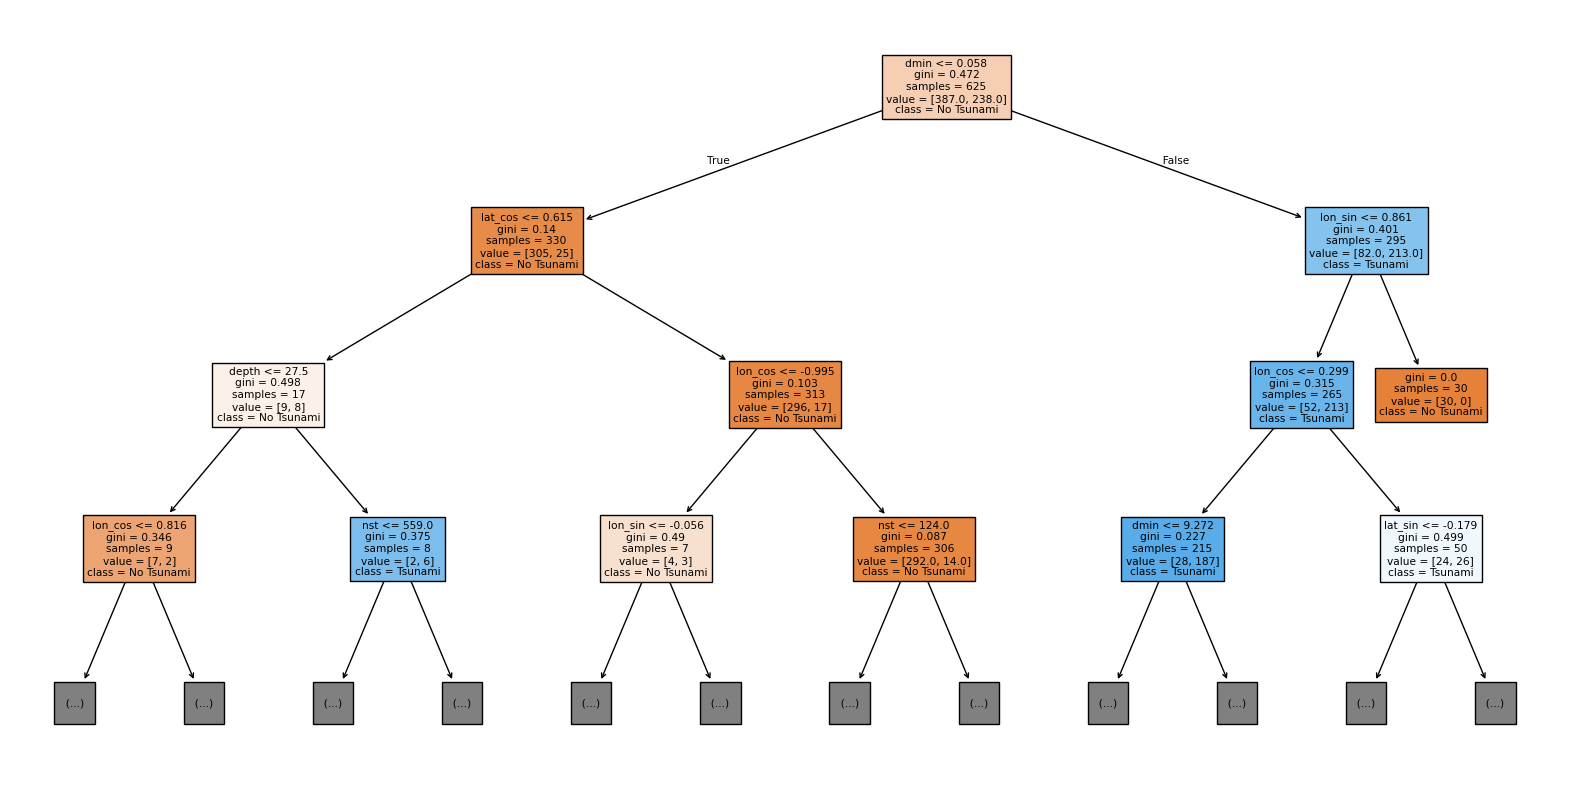

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=input_cols, class_names=['No Tsunami', 'Tsunami'], max_depth=3)
plt.show()

In [21]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    train_error = 1 - model.score(X_train, y_train)
    test_error = 1 - model.score(X_test, y_test)
    return {'max_depth': md, 'train_error': train_error, 'test_error': test_error}

In [22]:
error_df = pd.DataFrame([max_depth_error(md) for md in range(1, 14)])
error_df

,max_depth,train_error,test_error
0,1,0.1712,0.178344
1,2,0.1232,0.114650
2,3,0.1168,0.101911
3,4,0.0880,0.121019
4,5,0.0752,0.133758
5,6,0.0576,0.140127
6,7,0.0480,0.152866
7,8,0.0304,0.159236
8,9,0.0224,0.159236
9,10,0.0160,0.140127


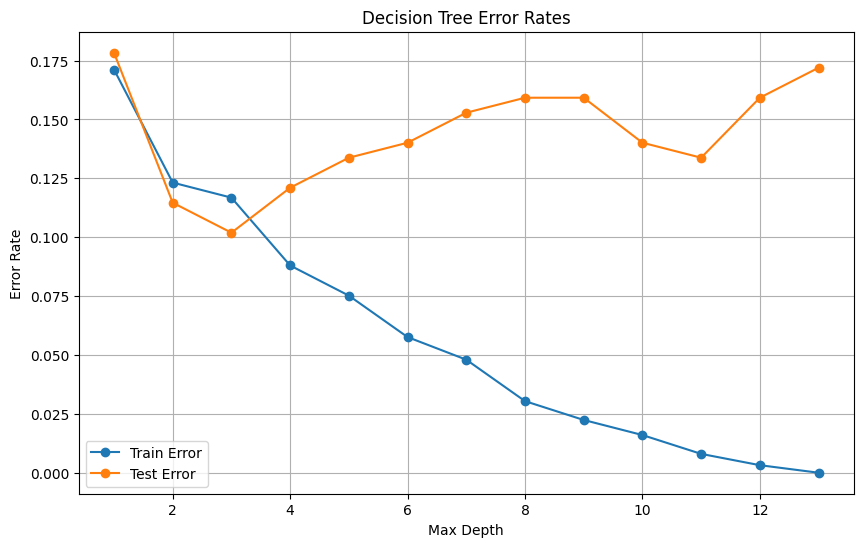

In [23]:
#plotting the error rates
plt.figure(figsize=(10,6))
plt.plot(error_df['max_depth'], error_df['train_error'], label='Train Error', marker='o')
plt.plot(error_df['max_depth'], error_df['test_error'], label='Test Error', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Error Rate')
plt.title('Decision Tree Error Rates')
plt.legend()
plt.grid()
plt.show()

In [24]:
# we see that max_depth of 3 gives least error
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8980891719745223

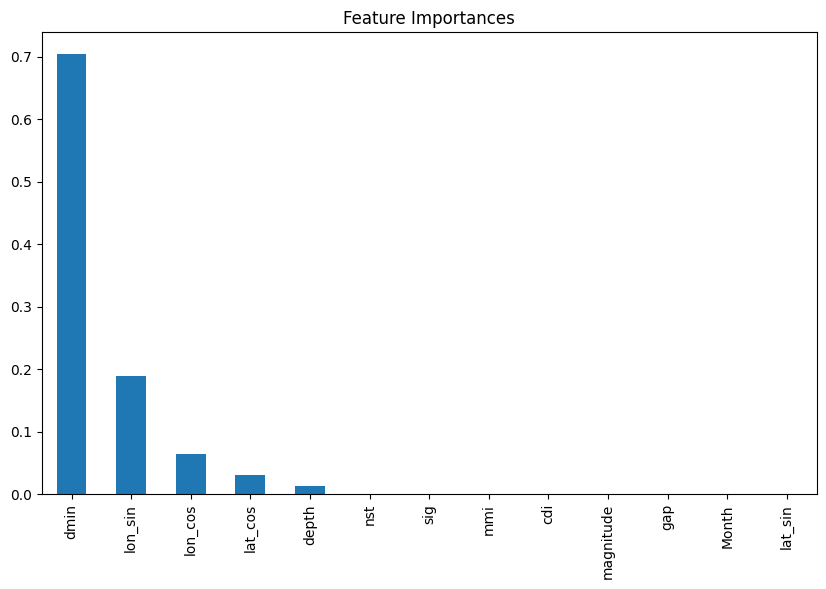

In [25]:
# checking feature importance
feature_importances = pd.Series(model.feature_importances_, index=input_cols).sort_values(ascending=False)
feature_importances.plot(kind='bar', figsize=(10,6))
plt.title('Feature Importances')
plt.show()

In [47]:
# manipulating max features
model = DecisionTreeClassifier(max_depth=3, max_features=12,random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9044585987261147

In [49]:
# we get the best fit 
model = DecisionTreeClassifier(max_depth=3, max_features=12, random_state=42)
model.fit(X_train, y_train)
print(f"Model Test Accuracy: {model.score(X_test, y_test)*100:.4f} %")

Model Test Accuracy: 90.4459 %


In [55]:
# predicting on new data
new_data = {
    'magnitude': [6.5],
    'cdi': [5.0],
    'mmi': [6.0],
    'sig': [500],
    'nst': [30],
    'dmin': [0.1],
    'gap': [45],
    'depth': [10.0],
    'Month': [7],
    'lat_sin': [np.sin(np.radians(34.05))],
    'lat_cos': [np.cos(np.radians(34.05))],
    'lon_sin': [np.sin(np.radians(-118.25))],
    'lon_cos': [np.cos(np.radians(-118.25))]
}
new_df = pd.DataFrame(new_data)
prediction = model.predict(new_df)
prediction_proba = model.predict_proba(new_df)
print(f"Predicted Tsunami Occurrence: {'Yes' if prediction[0] == 1 else 'No'}")
print(f"Prediction Probabilities: No Tsunami: {prediction_proba[0][0]:.4f}, Tsunami: {prediction_proba[0][1]:.4f}")

Predicted Tsunami Occurrence: Yes
Prediction Probabilities: No Tsunami: 0.2051, Tsunami: 0.7949
